# Autoencoders from scratch

*Part 0 (primer) of a 4-part speedrun on sparse autoencoders (SAEs) — everything you need to
reconstruct a [Neuronpedia](https://www.neuronpedia.org) feature dashboard from scratch,
and to train your own SAE on Gemma 3.*

This primer notebook will go from autoencoders to sparse autoencoders:

1. **The simplest autoencoder, a linear bottleneck** → we show that a linear bottleneck - the simplest autoencoder - trained with squared reconstruction error solves PCA
2. **How does ReLU enable superposition?** → we provide a justification for adding non-linearity (e.g. a ReLU) into our autoencoder, and we show it lets the model exploit sparsity by making errors occur only when features collide
2. **How is an SAE different from our dense autoencoders?** → an SAE is given only the dense network activation and tries to infer the sparse features that produced it.

Everything here runs on CPU in a few seconds — we use tiny toy models so the ground truth
is known and every claim is checkable. The real Gemma 3 work starts in Part 3.

# Two Networks That Look Alike

An autoencoder is one of the oldest ideas in representation learning: squeeze data
through a narrow channel and force it to come out the other side intact. A **sparse
autoencoder** — the tool this book is about — reuses that architecture almost verbatim,
and then inverts the point of it.

Putting them side by side is the fastest way to see what changes.

<figure style="margin:1.8rem auto;max-width:1000px">
  <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(330px,1fr));
              gap:1.2rem 1.8rem;align-items:start">
    <div>
<svg viewBox="0 0 420 330" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Undercomplete autoencoder: five inputs compressed to a two-unit bottleneck and reconstructed.</title>
<line x1="83" y1="130" x2="194" y2="147" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="130" x2="194" y2="189" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="168" x2="194" y2="147" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="168" x2="194" y2="189" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="244" x2="194" y2="147" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="244" x2="194" y2="189" stroke="currentColor" stroke-opacity="0.15"/>
<line x1="83" y1="92" x2="194" y2="147" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="92" x2="194" y2="189" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="194" y2="147" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="194" y2="189" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="226" y1="147" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="147" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.17"/>
<line x1="226" y1="189" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.17"/>
<text x="210" y="20" text-anchor="middle" font-size="14.5" font-weight="600" fill="currentColor">Undercomplete autoencoder</text>
<text x="210" y="38" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">compresses: m &lt; n</text>
<text x="140" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">encoder E</text>
<text x="280" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">decoder D</text>
<circle cx="70" cy="92" r="11" fill="#f08c00"/>
<circle cx="70" cy="130" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="70" cy="168" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="70" cy="206" r="11" fill="#f08c00"/>
<circle cx="70" cy="244" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="147" r="14" fill="#4c8dd6"/>
<circle cx="210" cy="189" r="14" fill="#4c8dd6"/>
<circle cx="350" cy="92" r="11" fill="#f08c00" fill-opacity="0.42"/>
<circle cx="350" cy="130" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="350" cy="168" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="350" cy="206" r="11" fill="#f08c00" fill-opacity="0.42"/>
<circle cx="350" cy="244" r="11" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<text x="70" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">x ∈ ℝⁿ</text>
<text x="70" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">input, n = 5</text>
<text x="210" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">h = Ex ∈ ℝᵐ</text>
<text x="210" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">bottleneck, m = 2</text>
<text x="350" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">x̂ = DEx ∈ ℝⁿ</text>
<text x="350" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">reconstruction</text>
</svg>
    </div>
    <div>
<svg viewBox="0 0 420 330" role="img" xmlns="http://www.w3.org/2000/svg"
     style="width:100%;height:auto;overflow:visible"
     font-family="system-ui,-apple-system,Segoe UI,sans-serif">
<title>Sparse autoencoder: a five-dimensional dense activation expanded into nine latents, only two of which are active, then reconstructed.</title>
<line x1="83" y1="92" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="130" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="168" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="206" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="76" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="99" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="145" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="191" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="237" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="244" x2="200" y2="260" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="83" y1="92" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="92" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="130" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="130" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="168" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="168" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="206" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="244" x2="200" y2="122" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="83" y1="244" x2="200" y2="214" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="76" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="76" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="99" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="145" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="168" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="191" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="237" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="92" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="130" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="168" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="206" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="260" x2="337" y2="244" stroke="currentColor" stroke-opacity="0.085"/>
<line x1="220" y1="122" x2="337" y2="92" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="130" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="168" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="206" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="122" x2="337" y2="244" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="92" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="130" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="168" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="206" stroke="#f08c00" stroke-opacity="0.34"/>
<line x1="220" y1="214" x2="337" y2="244" stroke="#f08c00" stroke-opacity="0.34"/>
<text x="210" y="20" text-anchor="middle" font-size="14.5" font-weight="600" fill="currentColor">Sparse (overcomplete) autoencoder</text>
<text x="210" y="38" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">expands: M &gt; n, but z is sparse</text>
<text x="136" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">encoder W<tspan font-size="9.5" dy="3">enc</tspan><tspan dy="-3">, ReLU</tspan></text>
<text x="286" y="58" text-anchor="middle" font-size="12.5" font-style="italic" fill="currentColor" opacity="0.72">decoder W<tspan font-size="9.5" dy="3">dec</tspan><tspan dy="-3"></tspan></text>
<circle cx="70" cy="92" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="130" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="168" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="206" r="11" fill="#4c8dd6"/>
<circle cx="70" cy="244" r="11" fill="#4c8dd6"/>
<circle cx="210" cy="76" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="99" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="122" r="8" fill="#f08c00"/>
<circle cx="210" cy="145" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="168" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="191" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="214" r="8" fill="#f08c00"/>
<circle cx="210" cy="237" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="210" cy="260" r="8" fill="none" stroke="currentColor" stroke-opacity="0.5"/>
<circle cx="350" cy="92" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="130" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="168" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="206" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<circle cx="350" cy="244" r="11" fill="#4c8dd6" fill-opacity="0.42"/>
<text x="70" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">h ∈ ℝⁿ</text>
<text x="70" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">dense activation, n = 5</text>
<text x="210" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">z ∈ ℝᴹ</text>
<text x="210" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">sparse latents, M = 9 (2 active)</text>
<text x="350" y="296" text-anchor="middle" font-size="13.5" fill="currentColor">ĥ = W<tspan font-size="9.5" dy="3">dec</tspan><tspan dy="-3"> z + </tspan>b<tspan font-size="9.5" dy="3">dec</tspan><tspan dy="-3"></tspan></text>
<text x="350" y="313" text-anchor="middle" font-size="11.5" fill="currentColor" opacity="0.62">reconstruction</text>
</svg>
    </div>
  </div>
  <div style="display:flex;flex-wrap:wrap;justify-content:center;gap:0.4rem 1.4rem;
              font-size:0.82em;opacity:0.75;margin-top:0.9rem">
    <span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="13" height="13" viewBox="0 0 13 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="#f08c00" fill-opacity="1"/></svg>active sparse feature</span><span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="13" height="13" viewBox="0 0 13 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="#4c8dd6" fill-opacity="1"/></svg>dense / mixed activation</span><span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="13" height="13" viewBox="0 0 13 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="currentColor" fill-opacity="0" stroke="currentColor" stroke-opacity="0.5"/></svg>zero (inactive)</span><span style="display:inline-flex;align-items:center;gap:0.4em"><svg width="13" height="13" viewBox="0 0 13 13" aria-hidden="true" style="flex:none"><circle cx="6.5" cy="6.5" r="5.5" fill="#f08c00" fill-opacity="0.42"/></svg>reconstructed (approximate)</span>
  </div>
  <figcaption style="font-size:0.9em;opacity:0.75;margin-top:0.9rem;
                     max-width:70ch;margin-left:auto;margin-right:auto;text-align:left">
    <strong>Left:</strong> the classical autoencoder squeezes an <em>n</em>-dimensional
    input through a narrower bottleneck (<em>m</em>&#160;&lt;&#160;<em>n</em>). The map
    <em>A</em>&#160;=&#160;<em>DE</em> has rank at most <em>m</em>, so every reconstruction
    lies in the column space of <em>D</em> — the model is <em>forced</em> to mix features
    together, and the reconstruction of one active feature bleeds into the coordinates of
    the others.
    <strong>Right:</strong> the sparse autoencoder runs the same machinery backwards. Its
    input is already a dense, mixed activation; the latent layer is <em>wider</em> than the
    input (<em>M</em>&#160;&gt;&#160;<em>n</em>), and what does the work is not a dimensional
    bottleneck but an <em>information</em> bottleneck — a sparsity penalty that keeps all but
    a handful of latents at zero. Highlighted edges show the sparse subnetwork that is
    actually carrying signal.
  </figcaption>
</figure>

## A familiar shape, running backwards

The toy model of superposition writes something like

$$
\hat{s} = \operatorname{ReLU}(W^\top W s).
$$

It *starts* with known sparse features $s$, compresses them into $h = Ws$, and asks
whether the network can reconstruct them. It is a model of the problem.

A sparse autoencoder writes something like

$$
z = \operatorname{ReLU}(W_{\text{enc}} h + b_{\text{enc}}),
\qquad
\hat{h} = W_{\text{dec}} z + b_{\text{dec}},
$$

trained on $\lVert h - \hat{h} \rVert_2^2 + \lambda \lVert z \rVert_1$. It *starts*
with the mixed activation $h$, infers sparse features $z$, and reconstructs $h$. It is a
model of the solution.

They look similar because both involve an encode and a decode. But the meanings of the
variables are reversed:

| | Toy superposition model | Sparse autoencoder |
| --- | --- | --- |
| **Input** | sparse ground-truth features | dense network activation |
| **Middle layer** | lower-dimensional than input | usually *higher*-dimensional |
| **Purpose** | demonstrates how superposition arises | tries to recover features from superposition |
| **Role of the ReLU** | suppresses output interference | produces sparse latent coefficients |

The overall picture is that the network we are studying performs

$$
\boxed{\;\text{sparse semantic features}
\;\overset{\text{superposition}}{\longrightarrow}\;
\text{dense residual activation}\;}
$$

and the sparse autoencoder tries to learn

$$
\boxed{\;\text{dense residual activation}
\;\overset{\text{sparse inference}}{\longrightarrow}\;
\text{sparse SAE features}\;}
$$

The SAE is deliberately doing the reverse. That is exactly why we use it.

# The simplest autoencoder: an undercomplete linear autoencoder

The simplest autoencoder is an **undercomplete linear autoencoder**: a linear encoder compresses the input into a lower-dimensional latent representation, and a linear decoder reconstructs the input from that representation. Specifically, we define:
- **linear**: both encoder and decoder are linear maps;
- **undercomplete**: the latent dimension is smaller than the input dimension, $m<n$;
- **autoencoder**: it is trained to reconstruct its input.

Let the input be

$$
x \in \mathbb{R}^n
$$

and let its lower-dimensional representation be

$$
h \in \mathbb{R}^m,
\qquad m<n.
$$

The encoder maps the input into the bottleneck:

$$
h = Ex,
\qquad
E \in \mathbb{R}^{m \times n}.
$$

The decoder maps the bottleneck back into the original space:

$$
\hat{x} = Dh,
\qquad
D \in \mathbb{R}^{n \times m}.
$$

Combining the encoder and decoder gives

$$
\hat{x} = DEx = Ax,
$$

where

$$
A = DE \in \mathbb{R}^{n \times n}.
$$

The full computation is therefore

$$
\mathbb{R}^n
\xrightarrow{E}
\mathbb{R}^m
\xrightarrow{D}
\mathbb{R}^n.
$$

Although $A$ maps an $n$-dimensional input to an $n$-dimensional output, the information must pass through an $m$-dimensional bottleneck. This means

$$
\operatorname{rank}(A) \leq m.
$$

Another way to see this is to consider the decoder. Every reconstruction has the form

$$
\hat{x} = Dh.
$$

Therefore, every reconstruction is a linear combination of the $m$ columns of $D$. Every possible output must lie in the column space of $D$:

$$
\hat{x} \in \operatorname{col}(D).
$$

Since $D$ has $m$ columns,

$$
\dim\left(\operatorname{col}(D)\right) \leq m.
$$

Thus, the linear autoencoder must reconstruct every input using a single shared subspace of dimension at most $m$.

Training the autoencoder means choosing $E$ and $D$, or equivalently choosing a linear map $A=DE$ with rank at most $m$, to minimise the average squared reconstruction error:

$$
\min_{\operatorname{rank}(A)\leq m}
\mathbb{E}_{x}
\left[
\left|x-Ax\right|_2^2
\right].
$$

In other words, the linear autoencoder tries to find the best $m$-dimensional linear subspace for reconstructing the data.


<figure style="margin:1.6rem auto;text-align:center;max-width:720px">
<svg viewBox="0 0 680 312" role="img" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;overflow:visible" font-family="system-ui,-apple-system,Segoe UI,sans-serif">

<text x="340" y="26" text-anchor="middle" font-size="15" font-weight="600" fill="currentColor">
Undercomplete linear autoencoder — an m-dimensional bottleneck (m &lt; n)
</text>

<!-- Encoder connections -->
<line x1="134" y1="70" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="70" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="112" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="112" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="154" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="154" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="196" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="196" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="238" x2="323" y2="133" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="134" y1="238" x2="323" y2="175" stroke="currentColor" stroke-opacity="0.16"/>

<!-- Decoder connections -->
<line x1="357" y1="133" x2="546" y2="70" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="112" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="154" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="196" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="133" x2="546" y2="238" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="70" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="112" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="154" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="196" stroke="currentColor" stroke-opacity="0.16"/>
<line x1="357" y1="175" x2="546" y2="238" stroke="currentColor" stroke-opacity="0.16"/>

<!-- Layer labels -->
<text x="230" y="91" text-anchor="middle" font-size="13" font-style="italic" fill="currentColor" opacity="0.72">
encoder E
</text>
<text x="450" y="91" text-anchor="middle" font-size="13" font-style="italic" fill="currentColor" opacity="0.72">
decoder D
</text>

<!-- Input nodes -->
<circle cx="120" cy="70" r="13" fill="#f08c00"/>
<circle cx="120" cy="112" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="120" cy="154" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="120" cy="196" r="13" fill="#f08c00"/>
<circle cx="120" cy="238" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>

<!-- Bottleneck nodes -->
<circle cx="340" cy="133" r="16" fill="#4c8dd6"/>
<circle cx="340" cy="175" r="16" fill="#4c8dd6"/>

<!-- Output nodes -->
<circle cx="560" cy="70" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="112" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="154" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="196" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>
<circle cx="560" cy="238" r="13" fill="none" stroke="currentColor" stroke-opacity="0.55"/>

<!-- Bottom labels -->
<text x="120" y="282" text-anchor="middle" font-size="14" fill="currentColor">
input x ∈ Rⁿ  (n = 5)
</text>

<text x="340" y="282" text-anchor="middle" font-size="14" fill="currentColor">
h = Ex ∈ Rᵐ  (m = 2)
</text>

<text x="340" y="300" text-anchor="middle" font-size="12" fill="currentColor" opacity="0.65">
bottleneck
</text>

<text x="560" y="282" text-anchor="middle" font-size="14" fill="currentColor">
x̂ = Dh = DEx ∈ Rⁿ
</text>

</svg>

<figcaption style="font-size:0.9em;opacity:0.72;margin-top:0.5rem">
A five-dimensional input <em>x</em> is compressed by the encoder <em>E</em> into a
two-dimensional latent representation <em>h</em>, then reconstructed by the decoder
<em>D</em>. Because <em>m</em>&nbsp;&lt;&nbsp;<em>n</em>, the combined map
<em>A</em> = <em>DE</em> has rank at most <em>m</em>, and every reconstruction
x̂ lies in the column space of <em>D</em>. Orange indicates an active input feature.
</figcaption>
</figure>

## Linear autoencoders recover the principal components

Suppose the centred datapoints are stored as the columns of

$$
X \in \mathbb{R}^{n \times N},
$$

where $n$ is the number of features and $N$ is the number of datapoints.

An undercomplete linear autoencoder reconstructs the data as

$$
\hat{X} = DEX = AX,
$$

where

$$
E \in \mathbb{R}^{m \times n},
\qquad
D \in \mathbb{R}^{n \times m},
\qquad
A = DE,
$$

and $m<n$. Since $A$ factors through an $m$-dimensional bottleneck,

$$
\operatorname{rank}(A) \leq m.
$$

Training the autoencoder with squared reconstruction error is equivalent to solving

$$
\min_{\operatorname{rank}(A)\leq m}
\left|X-AX\right|_F^2.
$$

### The truncated SVD

Let the singular value decomposition of $X$ be

$$
X = U\Sigma V^\top.
$$

The Eckart--Young theorem tells us that the best rank-$m$ approximation to $X$ is its truncated SVD:

$$
X_m = U_m\Sigma_m V_m^\top,
$$

where $U_m$ contains the first $m$ left singular vectors.

Now define

$$
A^* = U_mU_m^\top.
$$

This is the orthogonal projection onto the subspace spanned by the first $m$ left singular vectors. Applying it to the data gives

$$
A^*X = U_mU_m^\top U\Sigma V^\top.
$$

Because the columns of $U$ are orthonormal, $U_m^\top U$ selects the first $m$ rows of $\Sigma V^\top$. Therefore,

$$
A^*X = U_m\Sigma_mV_m^\top = X_m.
$$

Thus,

$$
\boxed{A^*X=X_m}.
$$

The optimal linear autoencoder therefore produces exactly the truncated-SVD approximation of the centred data. Its bottleneck preserves the subspace spanned by the first $m$ principal components.

### Encoder and decoder weights

One optimal solution is

$$
E = U_m^\top,
\qquad
D = U_m.
$$

The latent representation is then

$$
h = U_m^\top x,
$$

which contains the coordinates of $x$ along the first $m$ principal directions. The reconstruction is

$$
\hat{x} = U_mh = U_mU_m^\top x.
$$

This solution has tied weights:

$$
D=E^\top.
$$

However, the individual encoder and decoder matrices are not unique. For any invertible matrix

$$
R\in\mathbb{R}^{m\times m},
$$

we can instead choose

$$
E = RU_m^\top,
\qquad
D = U_mR^{-1}.
$$

Their product is unchanged:

$$
DE = U_mR^{-1}R U_m^\top = U_mU_m^\top.
$$

The matrix $R$ changes the coordinate system used inside the bottleneck, but it does not change the reconstruction.

If $R$ is orthogonal, then $R^{-1}=R^\top$ and the transformed solution also has tied weights:

$$
D=E^\top.
$$

For a general invertible $R$, the encoder and decoder are untied.

### Minimal numerical example


In [ ]:
import numpy as np

# Centred datapoints stored as columns
X = np.array([
    [-2.0, -1.0,  1.0,  2.0],
    [-1.8, -0.9,  0.9,  1.8],
    [ 0.2, -0.1,  0.1, -0.2],
]) # rank 2 matrix

m = 1

# Singular value decomposition
U, singular_values, Vt = np.linalg.svd(X, full_matrices=False)

# Keep the first m singular directions
U_m = U[:, :m]
S_m = np.diag(singular_values[:m])
Vt_m = Vt[:m, :]

# Truncated-SVD approximation
X_m = U_m @ S_m @ Vt_m

# Linear-autoencoder reconstruction
E = U_m.T
D = U_m
X_hat = D @ E @ X

# This autoencoder has a one-dimensional bottleneck and constructs the best rank-1 approximation $X_1$ to the rank-2 matrix $X$.
print(np.allclose(X_hat, X_m))


True



This prints

```text
True
```

because both procedures compute

$$
X_m = U_mU_m^\top X.
$$

The main result is therefore:

$$
\boxed{
\text{undercomplete linear autoencoder}
\quad\Longleftrightarrow\quad
\text{projection onto the principal-component subspace}
}
$$

# How do ReLUs enable superposition?

## The setup

A tiny tied-weight autoencoder: two input features squeezed through a **one-dimensional** bottleneck and back out again.

$$
x_A,\, x_B \;\longrightarrow\; h \;\longrightarrow\; \hat{x}_A,\, \hat{x}_B
$$

$$
h = Wx, \qquad \hat{x} = W^\top h = W^\top W x
$$

## Sparsity

Consider that our data is **sparse**: feature $x_A$ is rarely on when feature $x_B$ is, and vice versa. So in practice

$$
x \approx \begin{bmatrix} 1 \\ 0 \end{bmatrix}
\quad \text{or} \quad
\begin{bmatrix} 0 \\ 1 \end{bmatrix}
$$

In $x$-space the data lives (almost) entirely on the two axes. In $h$-space it collapses onto a line, with the two features landing on opposite sides of the origin.

## The bottleneck

Take $W = \begin{bmatrix} 1 & -1 \end{bmatrix}$:

$$
h = Wx = \begin{bmatrix} 1 & -1 \end{bmatrix}
\begin{bmatrix} x_A \\ x_B \end{bmatrix}
= x_A - x_B
$$

$$
x = \begin{bmatrix} 1 \\ 0 \end{bmatrix} \Rightarrow h = 1,
\qquad
x = \begin{bmatrix} 0 \\ 1 \end{bmatrix} \Rightarrow h = -1
$$

**The sign of $h$ tells us which feature is active.** One scalar is carrying two features — that's the superposition.

## The problem with tied weights

Because our weights are tied, $\hat{x} = W^\top W x$:

$$
\begin{bmatrix} \hat{x}_A \\ \hat{x}_B \end{bmatrix}
=
\begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}
\begin{bmatrix} x_A \\ x_B \end{bmatrix}
=
\begin{bmatrix} x_A - x_B \\ x_B - x_A \end{bmatrix}
$$

But this causes problems:

$$
x = \begin{bmatrix} 1 \\ 0 \end{bmatrix}
\;\Rightarrow\; h = 1
\;\Rightarrow\; \hat{x} = \begin{bmatrix} 1 \\ -1 \end{bmatrix}
\qquad \text{✗ wrong!}
$$

The $-1$ is an **interference** term in $B$: the decoder cannot help but read the "$A$ is on" signal as "$B$ is negatively on".

## The fix

If we add a ReLU:

$$
\mathrm{ReLU}\!\left(\begin{bmatrix} 1 \\ -1 \end{bmatrix}\right)
= \begin{bmatrix} 1 \\ 0 \end{bmatrix}
\qquad \text{✓ correct!}
$$

The interference happens to be *negative*, and features are non-negative, so the nonlinearity clips it away for free.

$$
\hat{x} = \mathrm{ReLU}\left(W^\top W x\right)
$$

## Where it still breaks

| point | $x$ | $h = x_A - x_B$ | $\hat{x} = W^\top W x$ | $\hat{x} = \mathrm{ReLU}(W^\top W x)$ |
|---|---|---|---|---|
| $A$ | $(0,0)$ | $0$ | $(0,0)$ ✓ | $(0,0)$ ✓ |
| $B$ | $(1,0)$ | $+1$ | $(1,-1)$ ✗ | $(1,0)$ ✓ |
| $C$ | $(0,1)$ | $-1$ | $(-1,1)$ ✗ | $(0,1)$ ✓ |
| $D$ | $(1,1)$ | $0$ | $(0,0)$ ✗ | $(0,0)$ ✗ |

**ReLU is still wrong when features co-fire, but is correct otherwise.** Point $D$ is indistinguishable from $A$ the moment it enters the bottleneck — $h = 0$ for both — and no decoder can recover information that was destroyed upstream.

## Takeaway

When your features are sparse (i.e. they don't co-fire), you can use a bottleneck to compress them, but doing so creates interference. A ReLU can then be used to remove some of that interference so that it actually works.





A: x=[0. 0.]  h=+0  xhat_lin=[0. 0.]  xhat_relu=[0. 0.]
B: x=[1. 0.]  h=+1  xhat_lin=[ 1. -1.]  xhat_relu=[1. 0.]
C: x=[0. 1.]  h=-1  xhat_lin=[-1.  1.]  xhat_relu=[0. 1.]
D: x=[1. 1.]  h=+0  xhat_lin=[0. 0.]  xhat_relu=[0. 0.]


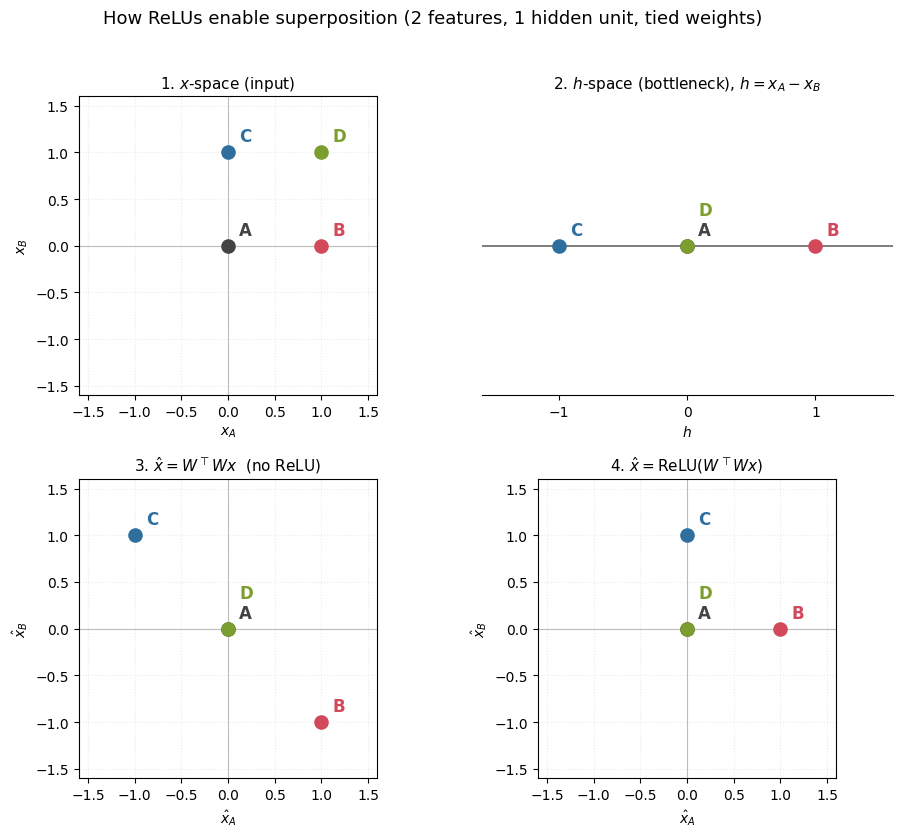

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# h    = W x            with W = [1, -1]
# xhat = W^T h          (linear)  or  ReLU(W^T h)
W = np.array([[1.0, -1.0]])          # shape (1, 2)

labels = ["A", "B", "C", "D"]
X = np.array([
    [0.0, 0.0],   # A: nothing on
    [1.0, 0.0],   # B: only feature A on
    [0.0, 1.0],   # C: only feature B on
    [1.0, 1.0],   # D: both on -> features co-fire, violates sparsity
])
colors = ["#444444", "#d1495b", "#2e6f9e", "#7b9e2e"]

H         = X @ W.T                  # (4, 1)  bottleneck code
Xhat_lin  = H @ W                    # (4, 2)  xhat = W^T W x
Xhat_relu = np.maximum(Xhat_lin, 0)  # (4, 2)  xhat = ReLU(W^T W x)

for lab, x, h, xl, xr in zip(labels, X, H, Xhat_lin, Xhat_relu):
    print(f"{lab}: x={x}  h={h[0]:+.0f}  xhat_lin={xl}  xhat_relu={xr}")


def scatter2d(ax, pts, title, xlabel, ylabel):
    ax.axhline(0, color="0.75", lw=0.8, zorder=0)
    ax.axvline(0, color="0.75", lw=0.8, zorder=0)
    seen = {}
    for lab, (px, py), c in zip(labels, pts, colors):
        ax.scatter(px, py, s=90, color=c, zorder=3)
        k = (round(px, 6), round(py, 6))          # stack labels when points coincide
        seen[k] = seen.get(k, 0) + 1
        ax.annotate(lab, (px, py), textcoords="offset points",
                    xytext=(8, 8 + 14 * (seen[k] - 1)), color=c,
                    fontsize=12, fontweight="bold")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect("equal")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.25, ls=":")


def scatter1d(ax, vals, title, xlabel):
    ax.axhline(0, color="0.4", lw=1.2, zorder=1)
    seen = {}
    for lab, v, c in zip(labels, vals.ravel(), colors):
        ax.scatter(v, 0, s=90, color=c, zorder=3)
        k = round(v, 6)
        seen[k] = seen.get(k, 0) + 1
        ax.annotate(lab, (v, 0), textcoords="offset points",
                    xytext=(8, 8 + 14 * (seen[k] - 1)), color=c,
                    fontsize=12, fontweight="bold")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.0, 1.0)
    ax.set_yticks([]); ax.set_xticks([-1, 0, 1])
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    ax.spines[["left", "right", "top"]].set_visible(False)


fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.5))

scatter2d(axes[0, 0], X, "1. $x$-space (input)", "$x_A$", "$x_B$")
scatter1d(axes[0, 1], H, "2. $h$-space (bottleneck), $h = x_A - x_B$", "$h$")
scatter2d(axes[1, 0], Xhat_lin,
          r"3. $\hat{x} = W^\top W x$  (no ReLU)", r"$\hat{x}_A$", r"$\hat{x}_B$")
scatter2d(axes[1, 1], Xhat_relu,
          r"4. $\hat{x} = \mathrm{ReLU}(W^\top W x)$", r"$\hat{x}_A$", r"$\hat{x}_B$")

fig.suptitle("How ReLUs enable superposition (2 features, 1 hidden unit, tied weights)",
             fontsize=13, y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

Reading the panels left-to-right, top-to-bottom: the four points start out distinct in $x$-space; the bottleneck collapses $A$ and $D$ onto the same value; the linear decoder pushes $B$ and $C$ off-axis into negative-interference territory; and the ReLU snaps them back onto the correct axes, leaving only the $A/D$ collision — the one error that was baked in before the decoder ever ran.